In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parent
project_root

PosixPath('/Users/yufeizhou/Desktop/heat-exposure-compare')

In [2]:
raw_dir = project_root / "data_raw"
processed_dir = project_root / "data_processed"
figure_dir = project_root / "figures" / "pilot"
output_dir = project_root / "outputs" / "pilot"

phoenix_raw = raw_dir / "phoenix"
houston_raw = raw_dir / "houston"

phoenix_processed = processed_dir / "phoenix"
houston_processed = processed_dir / "houston"

print("phoenix_raw:", phoenix_raw)
print("houston_raw:", houston_raw)
print("phoenix_processed:", phoenix_processed)
print("houston_processed:", houston_processed)
print("figure_dir:", figure_dir)
print("output_dir:", output_dir)

phoenix_raw: /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/phoenix
houston_raw: /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/houston
phoenix_processed: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix
houston_processed: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston
figure_dir: /Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot
output_dir: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot


In [3]:
inventory_path = output_dir / "pilot_inventory.csv"
source_registry_path = output_dir / "pilot_source_registry.csv"

inventory_df = pd.read_csv(inventory_path)
source_registry_df = pd.read_csv(source_registry_path)

print("Inventory:")
display(inventory_df)

print("Source registry:")
display(source_registry_df)

Inventory:


,city,climate_type,tract_boundary,lst_source,hi_source,demographic_source,city_boundary_source,status,raw_folder,processed_folder,figure_folder,notes
0,Phoenix,arid,US Census tract boundary,planned LST source,planned HI / moist heat source,ACS demographic variables,planned city/metro boundary,source plan drafted,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,pilot city: arid contrast city
1,Houston,humid subtropical,US Census tract boundary,planned LST source,planned HI / moist heat source,ACS demographic variables,planned city/metro boundary,source plan drafted,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,pilot city: humid contrast city


Source registry:


,city,climate_type,need_tract_boundary,need_lst,need_hi,need_demographic,need_city_boundary,priority,notes
0,Phoenix,arid,True,True,True,True,True,1,first pilot city
1,Houston,humid subtropical,True,True,True,True,True,1,second pilot city


In [4]:
import requests
import zipfile
from io import BytesIO

In [5]:
city_config = pd.DataFrame([
    {
        "city": "Houston",
        "state_fips": "48",
        "county_fips": "201",
        "county_name": "Harris County",
        "tract_zip_url": "https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_48_201_tract.zip",
        "raw_folder": str(houston_raw),
        "processed_folder": str(houston_processed)
    },
    {
        "city": "Phoenix",
        "state_fips": "04",
        "county_fips": "013",
        "county_name": "Maricopa County",
        "tract_zip_url": "https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_04_013_tract.zip",
        "raw_folder": str(phoenix_raw),
        "processed_folder": str(phoenix_processed)
    }
])

display(city_config)

,city,state_fips,county_fips,county_name,tract_zip_url,raw_folder,processed_folder
0,Houston,48,201,Harris County,https://www2.census.gov/geo/tiger/TIGER2025/TR...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...
1,Phoenix,04,013,Maricopa County,https://www2.census.gov/geo/tiger/TIGER2025/TR...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [7]:
city_config = pd.DataFrame([
    {
        "city": "Houston",
        "state_fips": "48",
        "county_fips": "201",
        "county_name": "Harris County",
        "tract_zip_url": "https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_48_tract.zip",
        "raw_folder": str(houston_raw),
        "processed_folder": str(houston_processed)
    },
    {
        "city": "Phoenix",
        "state_fips": "04",
        "county_fips": "013",
        "county_name": "Maricopa County",
        "tract_zip_url": "https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_04_tract.zip",
        "raw_folder": str(phoenix_raw),
        "processed_folder": str(phoenix_processed)
    }
])

display(city_config)

,city,state_fips,county_fips,county_name,tract_zip_url,raw_folder,processed_folder
0,Houston,48,201,Harris County,https://www2.census.gov/geo/tiger/TIGER2025/TR...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...
1,Phoenix,04,013,Maricopa County,https://www2.census.gov/geo/tiger/TIGER2025/TR...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [8]:
for _, row in city_config.iterrows():
    city = row["city"].lower()
    url = row["tract_zip_url"]
    raw_folder = Path(row["raw_folder"])
    
    zip_path = raw_folder / f"{city}_tract_2025.zip"
    
    print(f"\nDownloading {city} tract zip...")
    print("URL:", url)
    
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    
    zip_path.write_bytes(r.content)
    print("Saved to:", zip_path)
    print("File exists?", zip_path.exists())
    print("File size (MB):", round(zip_path.stat().st_size / 1024 / 1024, 2))


URL: https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_48_tract.zip
Saved to: /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/houston/houston_tract_2025.zip
File exists? True
File size (MB): 31.27

URL: https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_04_tract.zip
Saved to: /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/phoenix/phoenix_tract_2025.zip
File exists? True
File size (MB): 8.13


In [9]:
for _, row in city_config.iterrows():
    city = row["city"].lower()
    raw_folder = Path(row["raw_folder"])
    zip_path = raw_folder / f"{city}_tract_2025.zip"
    extract_folder = raw_folder / "tract_2025"
    
    extract_folder.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_folder)
    
    print(f"\nExtracted {city} files to:")
    print(extract_folder)
    print("Contents:")
    for p in sorted(extract_folder.iterdir()):
        print(" -", p.name)


Extracted houston files to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/houston/tract_2025
Contents:
 - tl_2025_48_tract.cpg
 - tl_2025_48_tract.dbf
 - tl_2025_48_tract.prj
 - tl_2025_48_tract.shp
 - tl_2025_48_tract.shp.ea.iso.xml
 - tl_2025_48_tract.shp.iso.xml
 - tl_2025_48_tract.shx

Extracted phoenix files to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/phoenix/tract_2025
Contents:
 - tl_2025_04_tract.cpg
 - tl_2025_04_tract.dbf
 - tl_2025_04_tract.prj
 - tl_2025_04_tract.shp
 - tl_2025_04_tract.shp.ea.iso.xml
 - tl_2025_04_tract.shp.iso.xml
 - tl_2025_04_tract.shx


In [10]:
def find_shp_file(folder: Path):
    shp_files = list(folder.glob("*.shp"))
    if len(shp_files) == 0:
        raise FileNotFoundError(f"No .shp file found in {folder}")
    if len(shp_files) > 1:
        print("Warning: multiple shp files found, using the first one.")
    return shp_files[0]

shp_registry = []

for _, row in city_config.iterrows():
    city = row["city"].lower()
    raw_folder = Path(row["raw_folder"])
    extract_folder = raw_folder / "tract_2025"
    shp_path = find_shp_file(extract_folder)
    
    shp_registry.append({
        "city": row["city"],
        "shp_path": str(shp_path)
    })

shp_registry_df = pd.DataFrame(shp_registry)
display(shp_registry_df)

,city,shp_path
0,Houston,/Users/yufeizhou/Desktop/heat-exposure-compare...
1,Phoenix,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [11]:
gdf_dict = {}

for _, row in shp_registry_df.iterrows():
    city = row["city"]
    shp_path = row["shp_path"]
    
    gdf = gpd.read_file(shp_path)
    gdf_dict[city] = gdf
    
    print(f"\n===== {city} =====")
    print("Rows:", len(gdf))
    print("CRS:", gdf.crs)
    print("Columns:")
    print(list(gdf.columns))


===== Houston =====
Rows: 6896
CRS: EPSG:4269
Columns:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']

===== Phoenix =====
Rows: 1765
CRS: EPSG:4269
Columns:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


In [12]:
county_gdf_dict = {}

for _, row in city_config.iterrows():
    city = row["city"]
    state_fips = row["state_fips"]
    county_fips = row["county_fips"]
    
    gdf = gdf_dict[city].copy()
    
    # 确保是字符串，避免前导 0 丢失
    gdf["STATEFP"] = gdf["STATEFP"].astype(str)
    gdf["COUNTYFP"] = gdf["COUNTYFP"].astype(str)
    gdf["GEOID"] = gdf["GEOID"].astype(str)
    
    county_gdf = gdf[
        (gdf["STATEFP"] == state_fips) &
        (gdf["COUNTYFP"] == county_fips)
    ].copy()
    
    county_gdf_dict[city] = county_gdf
    
    print(f"\n===== {city} county filtered =====")
    print("Rows:", len(county_gdf))
    print("Unique STATEFP:", county_gdf["STATEFP"].unique())
    print("Unique COUNTYFP:", county_gdf["COUNTYFP"].unique())
    print("Sample GEOIDs:", county_gdf["GEOID"].head().tolist())


===== Houston county filtered =====
Rows: 1115
Unique STATEFP: ['48']
Unique COUNTYFP: ['201']
Sample GEOIDs: ['48201342001', '48201421101', '48201423301', '48201453401', '48201331100']

===== Phoenix county filtered =====
Rows: 1009
Unique STATEFP: ['04']
Unique COUNTYFP: ['013']
Sample GEOIDs: ['04013061032', '04013061033', '04013061035', '04013061037', '04013061038']


In [13]:
clean_gdf_dict = {}

for city, gdf in county_gdf_dict.items():
    keep_cols = [
        c for c in [
            "STATEFP",
            "COUNTYFP",
            "TRACTCE",
            "GEOID",
            "NAME",
            "NAMELSAD",
            "ALAND",
            "AWATER",
            "geometry"
        ]
        if c in gdf.columns
    ]
    
    clean_gdf = gdf[keep_cols].copy()
    clean_gdf_dict[city] = clean_gdf
    
    print(f"\n===== {city} cleaned =====")
    print("Columns kept:", keep_cols)
    print(clean_gdf.head(3))


===== Houston cleaned =====
Columns kept: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'ALAND', 'AWATER', 'geometry']
  STATEFP COUNTYFP TRACTCE        GEOID     NAME              NAMELSAD  \
0      48      201  342001  48201342001  3420.01  Census Tract 3420.01   
1      48      201  421101  48201421101  4211.01  Census Tract 4211.01   
2      48      201  423301  48201423301  4233.01  Census Tract 4233.01   

     ALAND  AWATER                                           geometry  
0  5053185     772  POLYGON ((-95.14357 29.64973, -95.13828 29.649...  
1  1238555       0  POLYGON ((-95.47652 29.72445, -95.4765 29.7247...  
2  1654036   22924  POLYGON ((-95.5282 29.67272, -95.52642 29.6721...  

===== Phoenix cleaned =====
Columns kept: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'ALAND', 'AWATER', 'geometry']
  STATEFP COUNTYFP TRACTCE        GEOID    NAME             NAMELSAD    ALAND  \
1      04      013  061032  04013061032  610.32  Census Tr

In [14]:
for city, gdf in clean_gdf_dict.items():
    print(f"\n===== {city} geometry check =====")
    print("CRS:", gdf.crs)
    print("Geometry type:", gdf.geom_type.unique())
    print("Missing geometry:", gdf.geometry.isna().sum())
    print("Invalid geometry:", (~gdf.geometry.is_valid).sum())


===== Houston geometry check =====
CRS: EPSG:4269
Geometry type: ['Polygon']
Missing geometry: 0
Invalid geometry: 0

===== Phoenix geometry check =====
CRS: EPSG:4269
Geometry type: ['Polygon']
Missing geometry: 0
Invalid geometry: 0


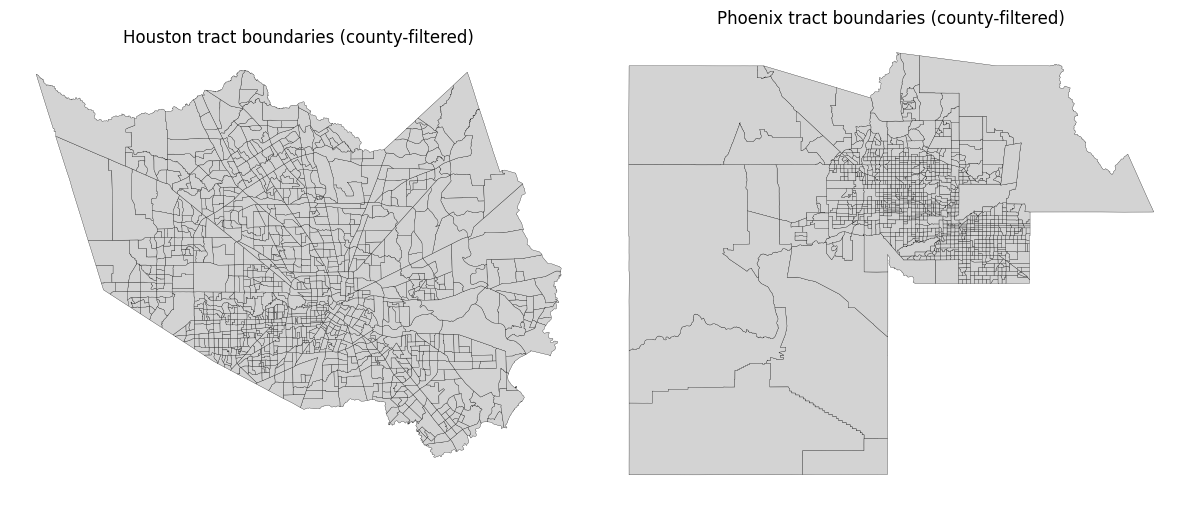

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, city in zip(axes, ["Houston", "Phoenix"]):
    clean_gdf_dict[city].plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.2
    )
    ax.set_title(f"{city} tract boundaries (county-filtered)")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [16]:
for city, gdf in clean_gdf_dict.items():
    city_lower = city.lower()
    out_path = project_root / "data_processed" / city_lower / f"{city_lower}_tracts_clean.geojson"
    
    gdf.to_file(out_path, driver="GeoJSON")
    
    print(f"\nSaved {city} clean tracts to:")
    print(out_path)
    print("Exists?", out_path.exists())


Saved Houston clean tracts to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_tracts_clean.geojson
Exists? True

Saved Phoenix clean tracts to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_tracts_clean.geojson
Exists? True


In [17]:
check_outputs = [
    project_root / "data_processed" / "houston" / "houston_tracts_clean.geojson",
    project_root / "data_processed" / "phoenix" / "phoenix_tracts_clean.geojson",
]

for p in check_outputs:
    print(p, "->", p.exists())

/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_tracts_clean.geojson -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_tracts_clean.geojson -> True


In [18]:
geoid_qc = []

for city, gdf in clean_gdf_dict.items():
    total_rows = len(gdf)
    unique_geoids = gdf["GEOID"].nunique()
    duplicated_geoids = gdf["GEOID"].duplicated().sum()
    
    geoid_qc.append({
        "city": city,
        "total_rows": total_rows,
        "unique_geoids": unique_geoids,
        "duplicated_geoids": duplicated_geoids
    })
    
    print(f"\n===== {city} GEOID check =====")
    print("Total rows:", total_rows)
    print("Unique GEOIDs:", unique_geoids)
    print("Duplicated GEOIDs:", duplicated_geoids)

geoid_qc_df = pd.DataFrame(geoid_qc)
geoid_qc_df


===== Houston GEOID check =====
Total rows: 1115
Unique GEOIDs: 1115
Duplicated GEOIDs: 0

===== Phoenix GEOID check =====
Total rows: 1009
Unique GEOIDs: 1009
Duplicated GEOIDs: 0


,city,total_rows,unique_geoids,duplicated_geoids
0,Houston,1115,1115,0
1,Phoenix,1009,1009,0


In [19]:
target_crs_dict = {
    "Houston": "EPSG:32615",  # UTM zone 15N
    "Phoenix": "EPSG:32612"   # UTM zone 12N
}

target_crs_dict

{'Houston': 'EPSG:32615', 'Phoenix': 'EPSG:32612'}

In [20]:
projected_gdf_dict = {}

for city, gdf in clean_gdf_dict.items():
    target_crs = target_crs_dict[city]
    
    gdf_proj = gdf.to_crs(target_crs).copy()
    

    gdf_proj["area_km2"] = gdf_proj.geometry.area / 1_000_000
    
    projected_gdf_dict[city] = gdf_proj
    
    print(f"\n===== {city} projected =====")
    print("Original CRS:", gdf.crs)
    print("Projected CRS:", gdf_proj.crs)
    print("Area summary (km²):")
    print(gdf_proj["area_km2"].describe())


===== Houston projected =====
Original CRS: EPSG:4269
Projected CRS: EPSG:32615
Area summary (km²):
count    1115.000000
mean        4.130009
std         8.806659
min         0.129633
25%         1.198574
50%         1.988361
75%         3.651301
max       135.040990
Name: area_km2, dtype: float64

===== Phoenix projected =====
Original CRS: EPSG:4269
Projected CRS: EPSG:32612
Area summary (km²):
count    1009.000000
mean       23.675899
std       202.339280
min         0.320874
25%         1.467409
50%         2.583635
75%         4.001784
max      3455.720614
Name: area_km2, dtype: float64


In [21]:
area_qc = []

for city, gdf in projected_gdf_dict.items():
    area_qc.append({
        "city": city,
        "tract_count": len(gdf),
        "min_area_km2": gdf["area_km2"].min(),
        "median_area_km2": gdf["area_km2"].median(),
        "max_area_km2": gdf["area_km2"].max(),
        "mean_area_km2": gdf["area_km2"].mean()
    })

area_qc_df = pd.DataFrame(area_qc)
area_qc_df

,city,tract_count,min_area_km2,median_area_km2,max_area_km2,mean_area_km2
0,Houston,1115,0.129633,1.988361,135.040990,4.130009
1,Phoenix,1009,0.320874,2.583635,3455.720614,23.675899


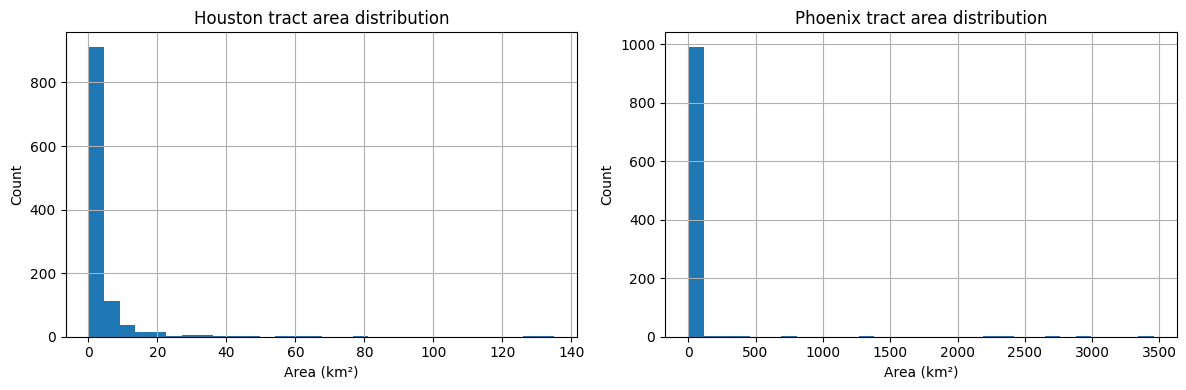

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["Houston", "Phoenix"]):
    projected_gdf_dict[city]["area_km2"].hist(ax=ax, bins=30)
    ax.set_title(f"{city} tract area distribution")
    ax.set_xlabel("Area (km²)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [23]:
for city, gdf in projected_gdf_dict.items():
    city_lower = city.lower()
    out_path = project_root / "data_processed" / city_lower / f"{city_lower}_tracts_projected.gpkg"
    
    gdf.to_file(out_path, layer="tracts", driver="GPKG")
    
    print(f"\nSaved {city} projected tracts to:")
    print(out_path)
    print("Exists?", out_path.exists())


Saved Houston projected tracts to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_tracts_projected.gpkg
Exists? True

Saved Phoenix projected tracts to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_tracts_projected.gpkg
Exists? True


In [24]:
geoid_qc_path = project_root / "outputs" / "pilot" / "geoid_qc.csv"
area_qc_path = project_root / "outputs" / "pilot" / "area_qc.csv"

geoid_qc_df.to_csv(geoid_qc_path, index=False)
area_qc_df.to_csv(area_qc_path, index=False)

print("Saved:")
print(geoid_qc_path, "->", geoid_qc_path.exists())
print(area_qc_path, "->", area_qc_path.exists())

Saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/geoid_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/area_qc.csv -> True


In [25]:
final_check = [
    project_root / "data_processed" / "houston" / "houston_tracts_projected.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_tracts_projected.gpkg",
    project_root / "outputs" / "pilot" / "geoid_qc.csv",
    project_root / "outputs" / "pilot" / "area_qc.csv",
]

for p in final_check:
    print(p, "->", p.exists())

/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_tracts_projected.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_tracts_projected.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/geoid_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/area_qc.csv -> True


In [26]:
place_config = pd.DataFrame([
    {
        "city": "Houston",
        "state_name": "Texas",
        "place_zip_url": "https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_48_place.zip",
        "raw_folder": str(houston_raw)
    },
    {
        "city": "Phoenix",
        "state_name": "Arizona",
        "place_zip_url": "https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_04_place.zip",
        "raw_folder": str(phoenix_raw)
    }
])

display(place_config)

,city,state_name,place_zip_url,raw_folder
0,Houston,Texas,https://www2.census.gov/geo/tiger/TIGER2025/PL...,/Users/yufeizhou/Desktop/heat-exposure-compare...
1,Phoenix,Arizona,https://www2.census.gov/geo/tiger/TIGER2025/PL...,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [27]:
for _, row in place_config.iterrows():
    city = row["city"].lower()
    url = row["place_zip_url"]
    raw_folder = Path(row["raw_folder"])
    
    zip_path = raw_folder / f"{city}_place_2025.zip"
    
    print(f"\nDownloading {city} place zip...")
    print("URL:", url)
    
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    
    zip_path.write_bytes(r.content)
    print("Saved to:", zip_path)
    print("Exists?", zip_path.exists())
    print("File size (MB):", round(zip_path.stat().st_size / 1024 / 1024, 2))


URL: https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_48_place.zip
Saved to: /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/houston/houston_place_2025.zip
Exists? True
File size (MB): 9.33

URL: https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_04_place.zip
Saved to: /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/phoenix/phoenix_place_2025.zip
Exists? True
File size (MB): 2.69


In [28]:
for _, row in place_config.iterrows():
    city = row["city"].lower()
    raw_folder = Path(row["raw_folder"])
    zip_path = raw_folder / f"{city}_place_2025.zip"
    extract_folder = raw_folder / "place_2025"
    
    extract_folder.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_folder)
    
    print(f"\nExtracted {city} place files to:")
    print(extract_folder)
    print("Contents:")
    for p in sorted(extract_folder.iterdir()):
        print(" -", p.name)


Extracted houston place files to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/houston/place_2025
Contents:
 - tl_2025_48_place.cpg
 - tl_2025_48_place.dbf
 - tl_2025_48_place.prj
 - tl_2025_48_place.shp
 - tl_2025_48_place.shp.ea.iso.xml
 - tl_2025_48_place.shp.iso.xml
 - tl_2025_48_place.shx

Extracted phoenix place files to:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/phoenix/place_2025
Contents:
 - tl_2025_04_place.cpg
 - tl_2025_04_place.dbf
 - tl_2025_04_place.prj
 - tl_2025_04_place.shp
 - tl_2025_04_place.shp.ea.iso.xml
 - tl_2025_04_place.shp.iso.xml
 - tl_2025_04_place.shx


In [29]:
place_shp_registry = []

for _, row in place_config.iterrows():
    city = row["city"]
    raw_folder = Path(row["raw_folder"])
    extract_folder = raw_folder / "place_2025"
    shp_path = find_shp_file(extract_folder)
    
    place_shp_registry.append({
        "city": city,
        "shp_path": str(shp_path)
    })

place_shp_registry_df = pd.DataFrame(place_shp_registry)
display(place_shp_registry_df)

,city,shp_path
0,Houston,/Users/yufeizhou/Desktop/heat-exposure-compare...
1,Phoenix,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [30]:
place_gdf_dict = {}

for _, row in place_shp_registry_df.iterrows():
    city = row["city"]
    shp_path = row["shp_path"]
    
    gdf = gpd.read_file(shp_path)
    place_gdf_dict[city] = gdf
    
    print(f"\n===== {city} place file =====")
    print("Rows:", len(gdf))
    print("CRS:", gdf.crs)
    print("Columns:")
    print(list(gdf.columns))


===== Houston place file =====
Rows: 1863
CRS: EPSG:4269
Columns:
['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'PCICBSA', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']

===== Phoenix place file =====
Rows: 467
CRS: EPSG:4269
Columns:
['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'PCICBSA', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


In [31]:
city_boundary_dict = {}

for city, gdf in place_gdf_dict.items():

    print(f"\n===== {city} candidate names =====")
    candidates = gdf[gdf["NAME"].str.contains(city, case=False, na=False)][["NAME"]].drop_duplicates()
    display(candidates)


===== Houston candidate names =====


,NAME
448,Houston
751,South Houston



===== Phoenix candidate names =====


,NAME
74,Phoenix


In [32]:
for city, gdf in place_gdf_dict.items():
    boundary = gdf[gdf["NAME"].str.upper() == city.upper()].copy()
    
    print(f"\n===== {city} selected boundary =====")
    print("Rows:", len(boundary))
    if len(boundary) > 0:
        display(boundary[["NAME"]].head())
    
    city_boundary_dict[city] = boundary


===== Houston selected boundary =====
Rows: 1


,NAME
448,Houston



===== Phoenix selected boundary =====
Rows: 1


,NAME
74,Phoenix


In [33]:
city_boundary_proj_dict = {}

for city, boundary_gdf in city_boundary_dict.items():
    target_crs = target_crs_dict[city]
    boundary_proj = boundary_gdf.to_crs(target_crs).copy()
    city_boundary_proj_dict[city] = boundary_proj
    
    print(f"\n===== {city} boundary projected =====")
    print("Original CRS:", boundary_gdf.crs)
    print("Projected CRS:", boundary_proj.crs)
    print("Rows:", len(boundary_proj))


===== Houston boundary projected =====
Original CRS: EPSG:4269
Projected CRS: EPSG:32615
Rows: 1

===== Phoenix boundary projected =====
Original CRS: EPSG:4269
Projected CRS: EPSG:32612
Rows: 1


In [34]:
city_tracts_dict = {}

for city in ["Houston", "Phoenix"]:
    target_crs = target_crs_dict[city]
    

    statewide_tracts_proj = gdf_dict[city].to_crs(target_crs).copy()
    

    city_boundary_proj = city_boundary_proj_dict[city]
    city_union = city_boundary_proj.geometry.union_all()
    

    selected = statewide_tracts_proj[statewide_tracts_proj.intersects(city_union)].copy()
    

    keep_cols = [
        c for c in [
            "STATEFP", "COUNTYFP", "TRACTCE", "GEOID",
            "NAME", "NAMELSAD", "ALAND", "AWATER", "geometry"
        ] if c in selected.columns
    ]
    selected = selected[keep_cols].copy()
    selected["GEOID"] = selected["GEOID"].astype(str)
    selected["area_km2"] = selected.geometry.area / 1_000_000
    
    city_tracts_dict[city] = selected
    
    print(f"\n===== {city} city tracts =====")
    print("Rows:", len(selected))
    print("Unique counties:", selected["COUNTYFP"].astype(str).nunique())
    print("Sample counties:", sorted(selected["COUNTYFP"].astype(str).unique())[:10])


===== Houston city tracts =====
Rows: 1113
Unique counties: 5
Sample counties: ['039', '157', '201', '339', '473']

===== Phoenix city tracts =====
Rows: 434
Unique counties: 1
Sample counties: ['013']


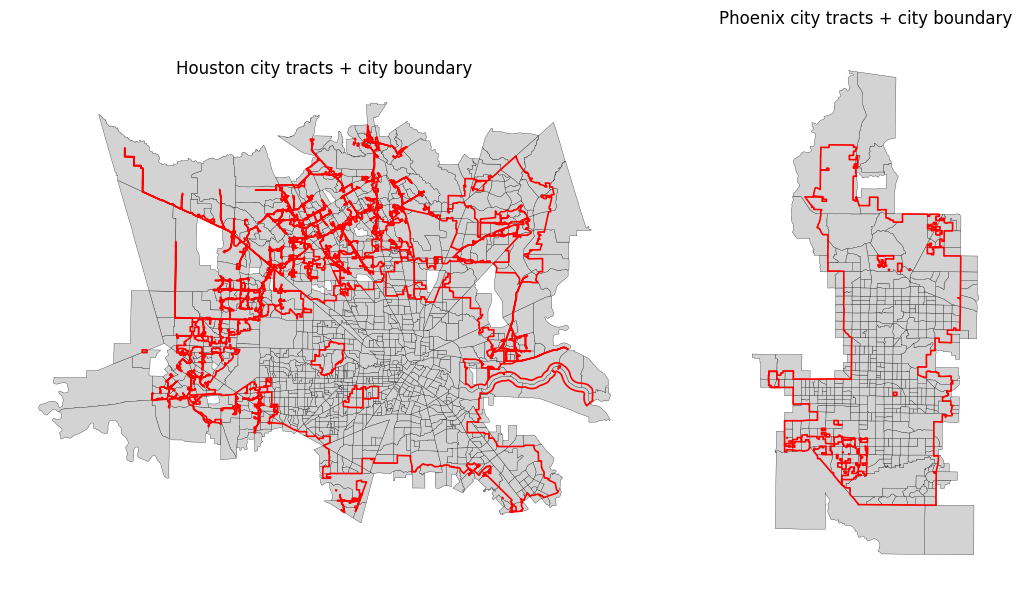

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, city in zip(axes, ["Houston", "Phoenix"]):
    city_tracts_dict[city].plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.2
    )
    city_boundary_proj_dict[city].boundary.plot(
        ax=ax,
        color="red",
        linewidth=1.2
    )
    ax.set_title(f"{city} city tracts + city boundary")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [36]:
city_final_check = [
    project_root / "data_processed" / "houston" / "houston_city_boundary.gpkg",
    project_root / "data_processed" / "houston" / "houston_city_tracts.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_city_boundary.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_city_tracts.gpkg",
]

for p in city_final_check:
    print(p, "->", p.exists())

/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_city_boundary.gpkg -> False
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_city_tracts.gpkg -> False
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_city_boundary.gpkg -> False
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_city_tracts.gpkg -> False


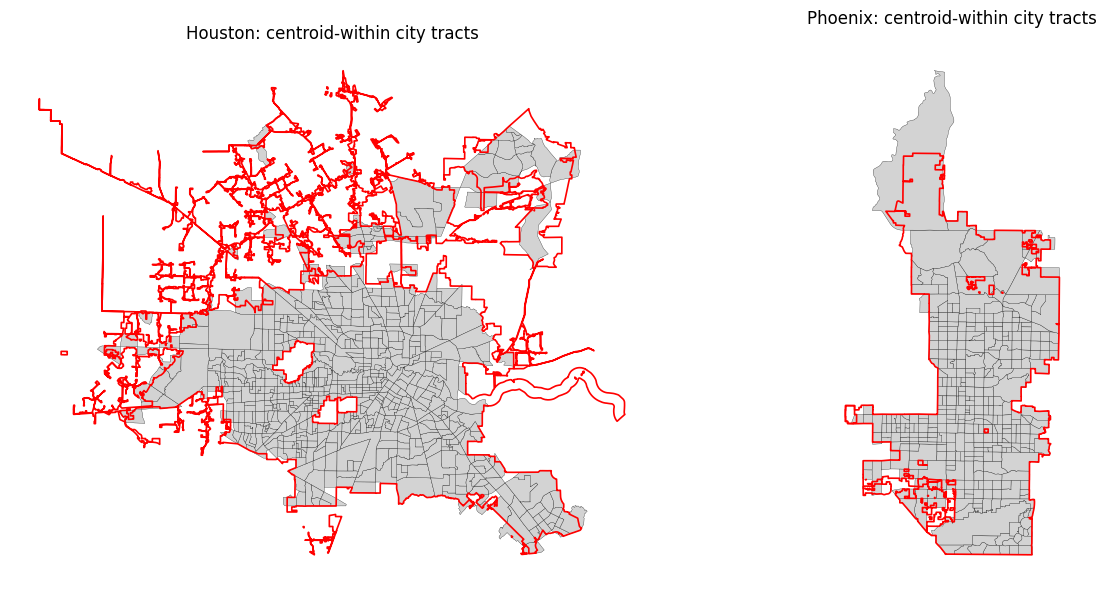

Save + selection summary:


,city,tract_count,unique_counties,sample_counties,boundary_saved,tracts_saved,boundary_path,tracts_path
0,Houston,654,2,"157, 201",True,True,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...
1,Phoenix,373,1,013,True,True,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...


QC figure saved to: /Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/city_tract_boundary_qc.png
QC figure exists? True


In [37]:
# =========================================================
# Rebuild city tracts using centroid-within-city rule
# This replaces the old intersects-based selection
# =========================================================

refined_city_tracts_dict = {}
save_records = []

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city in zip(axes, ["Houston", "Phoenix"]):
    target_crs = target_crs_dict[city]

    # 1) statewide tracts -> projected
    statewide_tracts_proj = gdf_dict[city].to_crs(target_crs).copy()

    # 2) city boundary -> projected
    city_boundary_proj = city_boundary_proj_dict[city].copy()
    city_union = city_boundary_proj.geometry.union_all()

    # 3) use centroid-within instead of intersects
    statewide_tracts_proj["centroid_geom"] = statewide_tracts_proj.geometry.centroid
    mask = statewide_tracts_proj["centroid_geom"].within(city_union)

    selected = statewide_tracts_proj.loc[mask].copy()

    # 4) keep only key columns
    keep_cols = [
        c for c in [
            "STATEFP", "COUNTYFP", "TRACTCE", "GEOID",
            "NAME", "NAMELSAD", "ALAND", "AWATER", "geometry"
        ] if c in selected.columns
    ]
    selected = selected[keep_cols].copy()

    # 5) standardize key fields
    selected["GEOID"] = selected["GEOID"].astype(str)
    selected["STATEFP"] = selected["STATEFP"].astype(str)
    selected["COUNTYFP"] = selected["COUNTYFP"].astype(str)

    # 6) area in km2
    selected["area_km2"] = selected.geometry.area / 1_000_000
    selected["city"] = city

    refined_city_tracts_dict[city] = selected

    # 7) plot QC map
    selected.plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.2
    )
    city_boundary_proj.boundary.plot(
        ax=ax,
        color="red",
        linewidth=1.2
    )
    ax.set_title(f"{city}: centroid-within city tracts")
    ax.set_axis_off()

    # 8) save boundary + tracts
    city_lower = city.lower()
    boundary_out = project_root / "data_processed" / city_lower / f"{city_lower}_city_boundary.gpkg"
    tracts_out = project_root / "data_processed" / city_lower / f"{city_lower}_city_tracts.gpkg"

    # remove old files if they exist, then rewrite cleanly
    for out_path in [boundary_out, tracts_out]:
        if out_path.exists():
            out_path.unlink()

    city_boundary_proj.to_file(boundary_out, layer="boundary", driver="GPKG")
    selected.to_file(tracts_out, layer="tracts", driver="GPKG")

    save_records.append({
        "city": city,
        "tract_count": len(selected),
        "unique_counties": selected["COUNTYFP"].nunique(),
        "sample_counties": ", ".join(sorted(selected["COUNTYFP"].unique())[:10]),
        "boundary_saved": boundary_out.exists(),
        "tracts_saved": tracts_out.exists(),
        "boundary_path": str(boundary_out),
        "tracts_path": str(tracts_out),
    })

plt.tight_layout()

qc_png = project_root / "figures" / "pilot" / "city_tract_boundary_qc.png"
plt.savefig(qc_png, dpi=300, bbox_inches="tight")
plt.show()

save_check_df = pd.DataFrame(save_records)
print("Save + selection summary:")
display(save_check_df)
print("QC figure saved to:", qc_png)
print("QC figure exists?", qc_png.exists())

In [38]:
# =========================================================
# Final QC after refined city tract selection
# =========================================================

summary_rows = []

for city, gdf in refined_city_tracts_dict.items():
    summary_rows.append({
        "city": city,
        "tract_count": len(gdf),
        "unique_geoids": gdf["GEOID"].nunique(),
        "duplicated_geoids": gdf["GEOID"].duplicated().sum(),
        "unique_counties": gdf["COUNTYFP"].nunique(),
        "min_area_km2": gdf["area_km2"].min(),
        "median_area_km2": gdf["area_km2"].median(),
        "max_area_km2": gdf["area_km2"].max(),
        "mean_area_km2": gdf["area_km2"].mean(),
    })

city_summary_df = pd.DataFrame(summary_rows)
display(city_summary_df)

summary_out = project_root / "outputs" / "pilot" / "city_tract_summary.csv"
city_summary_df.to_csv(summary_out, index=False)

final_check = [
    project_root / "data_processed" / "houston" / "houston_city_boundary.gpkg",
    project_root / "data_processed" / "houston" / "houston_city_tracts.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_city_boundary.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_city_tracts.gpkg",
    project_root / "figures" / "pilot" / "city_tract_boundary_qc.png",
    project_root / "outputs" / "pilot" / "city_tract_summary.csv",
]

print("\nFinal file check:")
for p in final_check:
    print(p, "->", p.exists())

print("\nQuick interpretation:")
for _, row in city_summary_df.iterrows():
    print(
        f"{row['city']}: tracts={row['tract_count']}, "
        f"unique_geoids={row['unique_geoids']}, "
        f"duplicated_geoids={row['duplicated_geoids']}, "
        f"unique_counties={row['unique_counties']}"
    )

,city,tract_count,unique_geoids,duplicated_geoids,unique_counties,min_area_km2,median_area_km2,max_area_km2,mean_area_km2
0,Houston,654,654,0,2,0.129633,1.488543,35.478451,2.369705
1,Phoenix,373,373,0,1,0.320874,2.408480,227.204372,3.994043



Final file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_city_boundary.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_city_tracts.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_city_boundary.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_city_tracts.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/city_tract_boundary_qc.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/city_tract_summary.csv -> True

Quick interpretation:
Houston: tracts=654, unique_geoids=654, duplicated_geoids=0, unique_counties=2
Phoenix: tracts=373, unique_geoids=373, duplicated_geoids=0, unique_counties=1


In [39]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------
project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

houston_tract_path = data_processed / "houston" / "houston_city_tracts.gpkg"
phoenix_tract_path = data_processed / "phoenix" / "phoenix_city_tracts.gpkg"

houston_gdf = gpd.read_file(houston_tract_path, layer="tracts")
phoenix_gdf = gpd.read_file(phoenix_tract_path, layer="tracts")

print("Houston tracts:", len(houston_gdf))
print("Phoenix tracts:", len(phoenix_gdf))

display(houston_gdf.head(2))
display(phoenix_gdf.head(2))

# --------------------------------------------------
# ACS helper
# --------------------------------------------------
ACS_YEAR = "2023"
ACS_BASE = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5"

# For now: total population + median household income
ACS_VARS = [
    "B01003_001E",  # total population
    "B19013_001E"   # median household income
]

def fetch_acs_tract_data_for_county(state_fips: str, county_fips: str, variables: list[str]) -> pd.DataFrame:
    """
    Download ACS tract-level data for one county.
    """
    var_string = ",".join(["NAME"] + variables)
    url = (
        f"{ACS_BASE}"
        f"?get={var_string}"
        f"&for=tract:*"
        f"&in=state:{state_fips}"
        f"&in=county:{county_fips}"
    )

    r = requests.get(url, timeout=60)
    r.raise_for_status()
    data = r.json()

    df = pd.DataFrame(data[1:], columns=data[0])

    # build GEOID = state + county + tract
    df["state"] = df["state"].astype(str)
    df["county"] = df["county"].astype(str)
    df["tract"] = df["tract"].astype(str)
    df["GEOID"] = df["state"] + df["county"] + df["tract"]

    # numeric conversion
    for v in variables:
        df[v] = pd.to_numeric(df[v], errors="coerce")

    return df

Houston tracts: 654
Phoenix tracts: 373


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,ALAND,AWATER,area_km2,city,geometry
0,48,201,421101,48201421101,4211.01,Census Tract 4211.01,1238555,0,1.239311,Houston,"POLYGON ((260450.376 3290821.22, 260452.777 32..."
1,48,201,423301,48201423301,4233.01,Census Tract 4233.01,1654036,22924,1.678074,Houston,"POLYGON ((255324.443 3285194.428, 255494.986 3..."


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,ALAND,AWATER,area_km2,city,geometry
0,04,013,117200,04013117200,1172,Census Tract 1172,7360771,0,7.356595,Phoenix,"POLYGON ((400977.05 3699411.24, 400977.764 369..."
1,04,013,082016,04013082016,820.16,Census Tract 820.16,5194775,1855,5.194239,Phoenix,"POLYGON ((381812.504 3708357.713, 381812.61 37..."


In [40]:
# --------------------------------------------------
# Figure out which counties each city uses
# --------------------------------------------------
def get_city_counties(gdf: gpd.GeoDataFrame, city_name: str) -> pd.DataFrame:
    out = (
        gdf[["STATEFP", "COUNTYFP"]]
        .astype(str)
        .drop_duplicates()
        .sort_values(["STATEFP", "COUNTYFP"])
        .reset_index(drop=True)
    )
    out["city"] = city_name
    return out

houston_counties = get_city_counties(houston_gdf, "Houston")
phoenix_counties = get_city_counties(phoenix_gdf, "Phoenix")

print("Houston counties:")
display(houston_counties)

print("Phoenix counties:")
display(phoenix_counties)

# --------------------------------------------------
# Download ACS for all counties involved in each city
# --------------------------------------------------
def fetch_city_acs(gdf: gpd.GeoDataFrame, city_name: str) -> pd.DataFrame:
    county_df = get_city_counties(gdf, city_name)

    parts = []
    for _, row in county_df.iterrows():
        state_fips = row["STATEFP"]
        county_fips = row["COUNTYFP"]

        print(f"Downloading ACS for {city_name}: state={state_fips}, county={county_fips}")
        part = fetch_acs_tract_data_for_county(
            state_fips=state_fips,
            county_fips=county_fips,
            variables=ACS_VARS
        )
        parts.append(part)

    acs_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset="GEOID").copy()

    acs_df = acs_df.rename(columns={
        "B01003_001E": "total_population",
        "B19013_001E": "median_household_income"
    })

    acs_df["city"] = city_name

    keep_cols = [
        "city", "GEOID", "NAME", "state", "county", "tract",
        "total_population", "median_household_income"
    ]
    return acs_df[keep_cols].copy()

houston_acs = fetch_city_acs(houston_gdf, "Houston")
phoenix_acs = fetch_city_acs(phoenix_gdf, "Phoenix")

print("\nHouston ACS:")
display(houston_acs.head())

print("\nPhoenix ACS:")
display(phoenix_acs.head())

# --------------------------------------------------
# Basic QC on ACS tables
# --------------------------------------------------
acs_qc = pd.DataFrame([
    {
        "city": "Houston",
        "acs_rows": len(houston_acs),
        "acs_unique_geoids": houston_acs["GEOID"].nunique(),
        "acs_missing_pop": houston_acs["total_population"].isna().sum(),
        "acs_missing_income": houston_acs["median_household_income"].isna().sum(),
    },
    {
        "city": "Phoenix",
        "acs_rows": len(phoenix_acs),
        "acs_unique_geoids": phoenix_acs["GEOID"].nunique(),
        "acs_missing_pop": phoenix_acs["total_population"].isna().sum(),
        "acs_missing_income": phoenix_acs["median_household_income"].isna().sum(),
    }
])

print("\nACS QC:")
display(acs_qc)

Houston counties:


,STATEFP,COUNTYFP,city
0,48,157,Houston
1,48,201,Houston


Phoenix counties:


,STATEFP,COUNTYFP,city
0,04,013,Phoenix



Houston ACS:


,city,GEOID,NAME,state,county,tract,total_population,median_household_income
0,Houston,48157670101,Census Tract 6701.01; Fort Bend County; Texas,48,157,670101,6123,62454
1,Houston,48157670102,Census Tract 6701.02; Fort Bend County; Texas,48,157,670102,3348,70198
2,Houston,48157670201,Census Tract 6702.01; Fort Bend County; Texas,48,157,670201,1687,105456
3,Houston,48157670202,Census Tract 6702.02; Fort Bend County; Texas,48,157,670202,5107,57017
4,Houston,48157670300,Census Tract 6703; Fort Bend County; Texas,48,157,670300,3429,49038



Phoenix ACS:


,city,GEOID,NAME,state,county,tract,total_population,median_household_income
0,Phoenix,04013010102,Census Tract 101.02; Maricopa County; Arizona,04,013,010102,6265,188486
1,Phoenix,04013010103,Census Tract 101.03; Maricopa County; Arizona,04,013,010103,3681,117813
2,Phoenix,04013010104,Census Tract 101.04; Maricopa County; Arizona,04,013,010104,3131,140587
3,Phoenix,04013030401,Census Tract 304.01; Maricopa County; Arizona,04,013,030401,4744,145865
4,Phoenix,04013030402,Census Tract 304.02; Maricopa County; Arizona,04,013,030402,4153,108031



ACS QC:


,city,acs_rows,acs_unique_geoids,acs_missing_pop,acs_missing_income
0,Houston,1248,1248,0,0
1,Phoenix,1009,1009,0,0


Master QC:


,city,tract_rows,unique_geoids,missing_pop_after_merge,missing_income_after_merge,total_population_sum,median_income_median
0,Houston,654,654,0,0,2314658,59713.0
1,Phoenix,373,373,0,0,1613480,75573.0


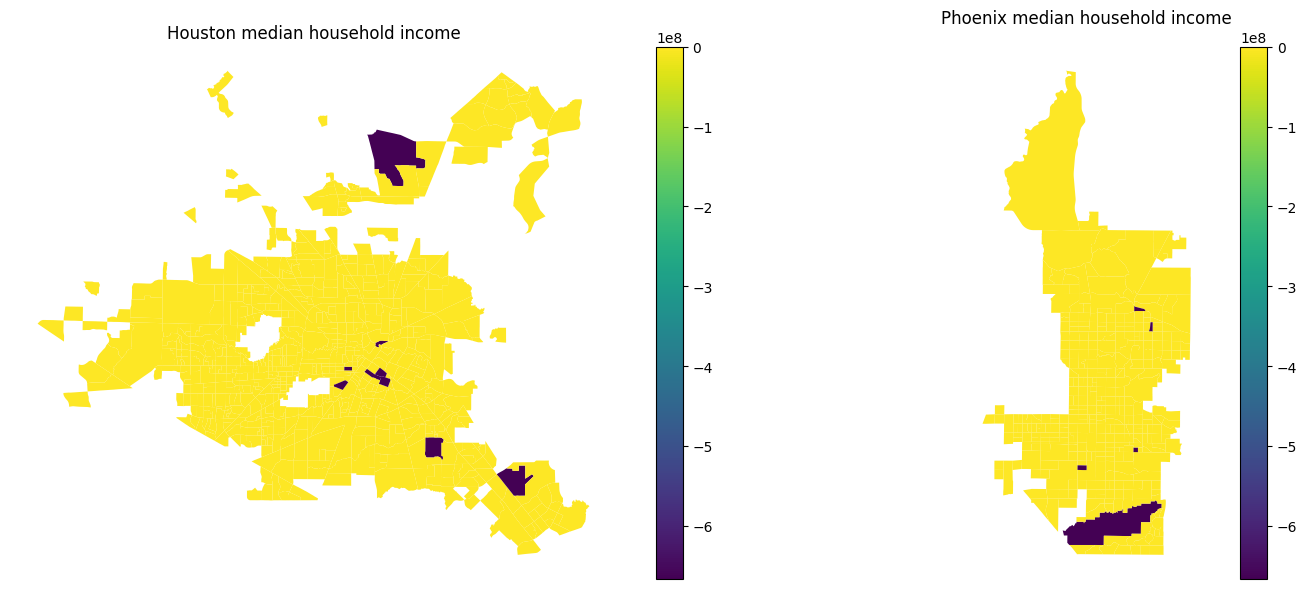


Final file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/houston_acs_2023.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/phoenix_acs_2023.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/acs_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/master_qc_demo.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/income_qc_map.png -> True


In [41]:
# --------------------------------------------------
# Merge ACS back to tract GeoDataFrame
# --------------------------------------------------
houston_master = houston_gdf.copy()
phoenix_master = phoenix_gdf.copy()

houston_master["GEOID"] = houston_master["GEOID"].astype(str)
phoenix_master["GEOID"] = phoenix_master["GEOID"].astype(str)

houston_master = houston_master.merge(
    houston_acs[["GEOID", "total_population", "median_household_income"]],
    on="GEOID",
    how="left"
)

phoenix_master = phoenix_master.merge(
    phoenix_acs[["GEOID", "total_population", "median_household_income"]],
    on="GEOID",
    how="left"
)

# --------------------------------------------------
# Master table QC
# --------------------------------------------------
master_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_master),
        "unique_geoids": houston_master["GEOID"].nunique(),
        "missing_pop_after_merge": houston_master["total_population"].isna().sum(),
        "missing_income_after_merge": houston_master["median_household_income"].isna().sum(),
        "total_population_sum": houston_master["total_population"].sum(skipna=True),
        "median_income_median": houston_master["median_household_income"].median(skipna=True)
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_master),
        "unique_geoids": phoenix_master["GEOID"].nunique(),
        "missing_pop_after_merge": phoenix_master["total_population"].isna().sum(),
        "missing_income_after_merge": phoenix_master["median_household_income"].isna().sum(),
        "total_population_sum": phoenix_master["total_population"].sum(skipna=True),
        "median_income_median": phoenix_master["median_household_income"].median(skipna=True)
    }
])

print("Master QC:")
display(master_qc)

# --------------------------------------------------
# Save outputs
# --------------------------------------------------
houston_master_out = data_processed / "houston" / "houston_master_demo.gpkg"
phoenix_master_out = data_processed / "phoenix" / "phoenix_master_demo.gpkg"

houston_master.to_file(houston_master_out, layer="tracts", driver="GPKG")
phoenix_master.to_file(phoenix_master_out, layer="tracts", driver="GPKG")

houston_acs_csv = output_dir / "houston_acs_2023.csv"
phoenix_acs_csv = output_dir / "phoenix_acs_2023.csv"
acs_qc_csv = output_dir / "acs_qc.csv"
master_qc_csv = output_dir / "master_qc_demo.csv"

houston_acs.to_csv(houston_acs_csv, index=False)
phoenix_acs.to_csv(phoenix_acs_csv, index=False)
acs_qc.to_csv(acs_qc_csv, index=False)
master_qc.to_csv(master_qc_csv, index=False)

# --------------------------------------------------
# Quick diagnostic map: median household income
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master.plot(
    column="median_household_income",
    ax=axes[0],
    legend=True
)
axes[0].set_title("Houston median household income")
axes[0].set_axis_off()

phoenix_master.plot(
    column="median_household_income",
    ax=axes[1],
    legend=True
)
axes[1].set_title("Phoenix median household income")
axes[1].set_axis_off()

plt.tight_layout()
income_map_out = figure_dir / "income_qc_map.png"
plt.savefig(income_map_out, dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Final check
# --------------------------------------------------
final_files = [
    houston_master_out,
    phoenix_master_out,
    houston_acs_csv,
    phoenix_acs_csv,
    acs_qc_csv,
    master_qc_csv,
    income_map_out
]

print("\nFinal file check:")
for p in final_files:
    print(p, "->", p.exists())

In [42]:
# =========================================================
# Step 1: inspect and clean ACS special values
# =========================================================

def inspect_numeric_series(s, name):
    print(f"\n===== {name} =====")
    print("dtype:", s.dtype)
    print("min:", s.min(skipna=True))
    print("max:", s.max(skipna=True))
    print("n_missing:", s.isna().sum())
    print("n_negative:", (s < 0).sum())
    print("smallest 10 values:")
    print(s.sort_values().head(10).tolist())

print("Before cleaning:")
inspect_numeric_series(houston_master["median_household_income"], "Houston median_household_income")
inspect_numeric_series(phoenix_master["median_household_income"], "Phoenix median_household_income")
inspect_numeric_series(houston_master["total_population"], "Houston total_population")
inspect_numeric_series(phoenix_master["total_population"], "Phoenix total_population")

# ---- clean rules ----
# total population should never be negative
# median household income should never be negative
for gdf in [houston_master, phoenix_master]:
    gdf["total_population_clean"] = gdf["total_population"].where(gdf["total_population"] >= 0)
    gdf["median_household_income_clean"] = gdf["median_household_income"].where(gdf["median_household_income"] >= 0)

print("\nAfter cleaning:")
inspect_numeric_series(houston_master["median_household_income_clean"], "Houston median_household_income_clean")
inspect_numeric_series(phoenix_master["median_household_income_clean"], "Phoenix median_household_income_clean")

demo_clean_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_master),
        "invalid_income_replaced_with_nan": houston_master["median_household_income_clean"].isna().sum()
            - houston_master["median_household_income"].isna().sum(),
        "invalid_population_replaced_with_nan": houston_master["total_population_clean"].isna().sum()
            - houston_master["total_population"].isna().sum(),
        "clean_income_median": houston_master["median_household_income_clean"].median(skipna=True),
        "clean_population_sum": houston_master["total_population_clean"].sum(skipna=True)
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_master),
        "invalid_income_replaced_with_nan": phoenix_master["median_household_income_clean"].isna().sum()
            - phoenix_master["median_household_income"].isna().sum(),
        "invalid_population_replaced_with_nan": phoenix_master["total_population_clean"].isna().sum()
            - phoenix_master["total_population"].isna().sum(),
        "clean_income_median": phoenix_master["median_household_income_clean"].median(skipna=True),
        "clean_population_sum": phoenix_master["total_population_clean"].sum(skipna=True)
    }
])

print("\nDemo clean QC:")
display(demo_clean_qc)

Before cleaning:

===== Houston median_household_income =====
dtype: int64
min: -666666666
max: 250001
n_missing: 0
n_negative: 9
smallest 10 values:
[-666666666, -666666666, -666666666, -666666666, -666666666, -666666666, -666666666, -666666666, -666666666, 14000]

===== Phoenix median_household_income =====
dtype: int64
min: -666666666
max: 250001
n_missing: 0
n_negative: 5
smallest 10 values:
[-666666666, -666666666, -666666666, -666666666, -666666666, 23232, 25296, 25306, 27604, 29615]

===== Houston total_population =====
dtype: int64
min: 0
max: 14134
n_missing: 0
n_negative: 0
smallest 10 values:
[0, 0, 14, 890, 1040, 1045, 1051, 1062, 1191, 1309]

===== Phoenix total_population =====
dtype: int64
min: 0
max: 8475
n_missing: 0
n_negative: 0
smallest 10 values:
[0, 0, 8, 696, 807, 911, 938, 1125, 1323, 1330]

After cleaning:

===== Houston median_household_income_clean =====
dtype: float64
min: 14000.0
max: 250001.0
n_missing: 9
n_negative: 0
smallest 10 values:
[14000.0, 16366.0

,city,tract_rows,invalid_income_replaced_with_nan,invalid_population_replaced_with_nan,clean_income_median,clean_population_sum
0,Houston,654,9,0,60167.0,2314658
1,Phoenix,373,5,0,75744.0,1613480


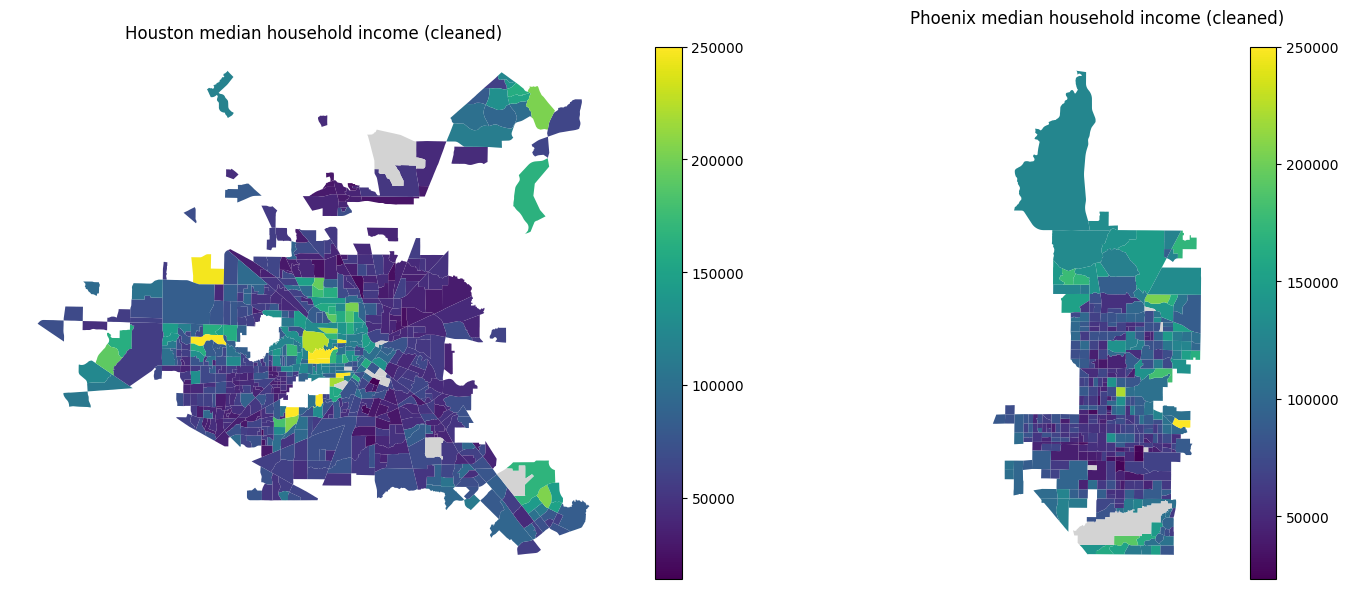


Final clean file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo_clean.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo_clean.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/demo_clean_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/income_qc_map_clean.png -> True


In [43]:
# =========================================================
# Step 2: save cleaned master tables + redraw QC maps
# =========================================================

# save cleaned master tables
houston_master_clean_out = data_processed / "houston" / "houston_master_demo_clean.gpkg"
phoenix_master_clean_out = data_processed / "phoenix" / "phoenix_master_demo_clean.gpkg"

houston_master.to_file(houston_master_clean_out, layer="tracts", driver="GPKG")
phoenix_master.to_file(phoenix_master_clean_out, layer="tracts", driver="GPKG")

# save qc table
demo_clean_qc_out = output_dir / "demo_clean_qc.csv"
demo_clean_qc.to_csv(demo_clean_qc_out, index=False)

# better QC map: use cleaned income and quantile-style display
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master.plot(
    column="median_household_income_clean",
    ax=axes[0],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing / invalid"}
)
axes[0].set_title("Houston median household income (cleaned)")
axes[0].set_axis_off()

phoenix_master.plot(
    column="median_household_income_clean",
    ax=axes[1],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing / invalid"}
)
axes[1].set_title("Phoenix median household income (cleaned)")
axes[1].set_axis_off()

plt.tight_layout()

income_clean_map_out = figure_dir / "income_qc_map_clean.png"
plt.savefig(income_clean_map_out, dpi=300, bbox_inches="tight")
plt.show()

# final check
final_clean_files = [
    houston_master_clean_out,
    phoenix_master_clean_out,
    demo_clean_qc_out,
    income_clean_map_out
]

print("\nFinal clean file check:")
for p in final_clean_files:
    print(p, "->", p.exists())

In [44]:
# =========================================================
# Step 3A: add poverty variables to the tract master table
# =========================================================

POVERTY_VARS = [
    "B17001_001E",  # poverty universe total
    "B17001_002E",  # below poverty level
]

def fetch_city_acs_with_vars(gdf: gpd.GeoDataFrame, city_name: str, vars_to_fetch: list[str]) -> pd.DataFrame:
    county_df = get_city_counties(gdf, city_name)

    parts = []
    for _, row in county_df.iterrows():
        state_fips = row["STATEFP"]
        county_fips = row["COUNTYFP"]

        print(f"Downloading ACS for {city_name}: state={state_fips}, county={county_fips}, vars={vars_to_fetch}")
        part = fetch_acs_tract_data_for_county(
            state_fips=state_fips,
            county_fips=county_fips,
            variables=vars_to_fetch
        )
        parts.append(part)

    acs_df = pd.concat(parts, ignore_index=True).drop_duplicates(subset="GEOID").copy()
    acs_df["city"] = city_name
    return acs_df

# ---- download poverty ACS
houston_poverty_acs = fetch_city_acs_with_vars(houston_gdf, "Houston", POVERTY_VARS)
phoenix_poverty_acs = fetch_city_acs_with_vars(phoenix_gdf, "Phoenix", POVERTY_VARS)

# ---- rename
houston_poverty_acs = houston_poverty_acs.rename(columns={
    "B17001_001E": "poverty_universe",
    "B17001_002E": "below_poverty_count"
})
phoenix_poverty_acs = phoenix_poverty_acs.rename(columns={
    "B17001_001E": "poverty_universe",
    "B17001_002E": "below_poverty_count"
})

print("\nHouston poverty ACS:")
display(houston_poverty_acs[["city", "GEOID", "NAME", "poverty_universe", "below_poverty_count"]].head())

print("\nPhoenix poverty ACS:")
display(phoenix_poverty_acs[["city", "GEOID", "NAME", "poverty_universe", "below_poverty_count"]].head())

# ---- make fresh copies of master tables
houston_master_v2 = houston_master.copy()
phoenix_master_v2 = phoenix_master.copy()

houston_master_v2["GEOID"] = houston_master_v2["GEOID"].astype(str)
phoenix_master_v2["GEOID"] = phoenix_master_v2["GEOID"].astype(str)

# if rerun, drop old poverty columns first
drop_cols = ["poverty_universe", "below_poverty_count", "poverty_universe_clean", "below_poverty_count_clean", "poverty_rate"]

houston_master_v2 = houston_master_v2.drop(columns=[c for c in drop_cols if c in houston_master_v2.columns], errors="ignore")
phoenix_master_v2 = phoenix_master_v2.drop(columns=[c for c in drop_cols if c in phoenix_master_v2.columns], errors="ignore")

# ---- merge poverty ACS
houston_master_v2 = houston_master_v2.merge(
    houston_poverty_acs[["GEOID", "poverty_universe", "below_poverty_count"]],
    on="GEOID",
    how="left"
)

phoenix_master_v2 = phoenix_master_v2.merge(
    phoenix_poverty_acs[["GEOID", "poverty_universe", "below_poverty_count"]],
    on="GEOID",
    how="left"
)

# ---- clean special values
for gdf in [houston_master_v2, phoenix_master_v2]:
    if "median_household_income_clean" not in gdf.columns:
        gdf["median_household_income_clean"] = gdf["median_household_income"].where(gdf["median_household_income"] >= 0)
    if "total_population_clean" not in gdf.columns:
        gdf["total_population_clean"] = gdf["total_population"].where(gdf["total_population"] >= 0)

    gdf["poverty_universe_clean"] = gdf["poverty_universe"].where(gdf["poverty_universe"] >= 0)
    gdf["below_poverty_count_clean"] = gdf["below_poverty_count"].where(gdf["below_poverty_count"] >= 0)

    gdf["poverty_rate"] = (
        gdf["below_poverty_count_clean"] / gdf["poverty_universe_clean"]
    )

    # prevent impossible values
    gdf.loc[(gdf["poverty_rate"] < 0) | (gdf["poverty_rate"] > 1), "poverty_rate"] = pd.NA

poverty_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_master_v2),
        "missing_poverty_universe": houston_master_v2["poverty_universe_clean"].isna().sum(),
        "missing_below_poverty": houston_master_v2["below_poverty_count_clean"].isna().sum(),
        "missing_poverty_rate": houston_master_v2["poverty_rate"].isna().sum(),
        "median_poverty_rate": houston_master_v2["poverty_rate"].median(skipna=True),
        "mean_poverty_rate": houston_master_v2["poverty_rate"].mean(skipna=True),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_master_v2),
        "missing_poverty_universe": phoenix_master_v2["poverty_universe_clean"].isna().sum(),
        "missing_below_poverty": phoenix_master_v2["below_poverty_count_clean"].isna().sum(),
        "missing_poverty_rate": phoenix_master_v2["poverty_rate"].isna().sum(),
        "median_poverty_rate": phoenix_master_v2["poverty_rate"].median(skipna=True),
        "mean_poverty_rate": phoenix_master_v2["poverty_rate"].mean(skipna=True),
    }
])

print("\nPoverty QC:")
display(poverty_qc)


Houston poverty ACS:


,city,GEOID,NAME,poverty_universe,below_poverty_count
0,Houston,48157670101,Census Tract 6701.01; Fort Bend County; Texas,6102,1053
1,Houston,48157670102,Census Tract 6701.02; Fort Bend County; Texas,3184,252
2,Houston,48157670201,Census Tract 6702.01; Fort Bend County; Texas,1687,44
3,Houston,48157670202,Census Tract 6702.02; Fort Bend County; Texas,5107,1119
4,Houston,48157670300,Census Tract 6703; Fort Bend County; Texas,3429,1011



Phoenix poverty ACS:


,city,GEOID,NAME,poverty_universe,below_poverty_count
0,Phoenix,04013010102,Census Tract 101.02; Maricopa County; Arizona,6265,762
1,Phoenix,04013010103,Census Tract 101.03; Maricopa County; Arizona,3681,473
2,Phoenix,04013010104,Census Tract 101.04; Maricopa County; Arizona,3131,140
3,Phoenix,04013030401,Census Tract 304.01; Maricopa County; Arizona,4672,406
4,Phoenix,04013030402,Census Tract 304.02; Maricopa County; Arizona,4153,263



Poverty QC:


,city,tract_rows,missing_poverty_universe,missing_below_poverty,missing_poverty_rate,median_poverty_rate,mean_poverty_rate
0,Houston,654,0,0,3,0.187448,0.198415
1,Phoenix,373,0,0,3,0.129445,0.152083


Inequity group counts:


,city,inequity_group,count
0,Houston,Low income + High poverty,271
1,Houston,High income + Low poverty,269
2,Houston,High income + High poverty,53
3,Houston,Low income + Low poverty,52
4,Houston,Missing,9
5,Phoenix,Low income + High poverty,147
6,Phoenix,High income + Low poverty,147
7,Phoenix,Low income + Low poverty,37
8,Phoenix,High income + High poverty,37
9,Phoenix,Missing,5


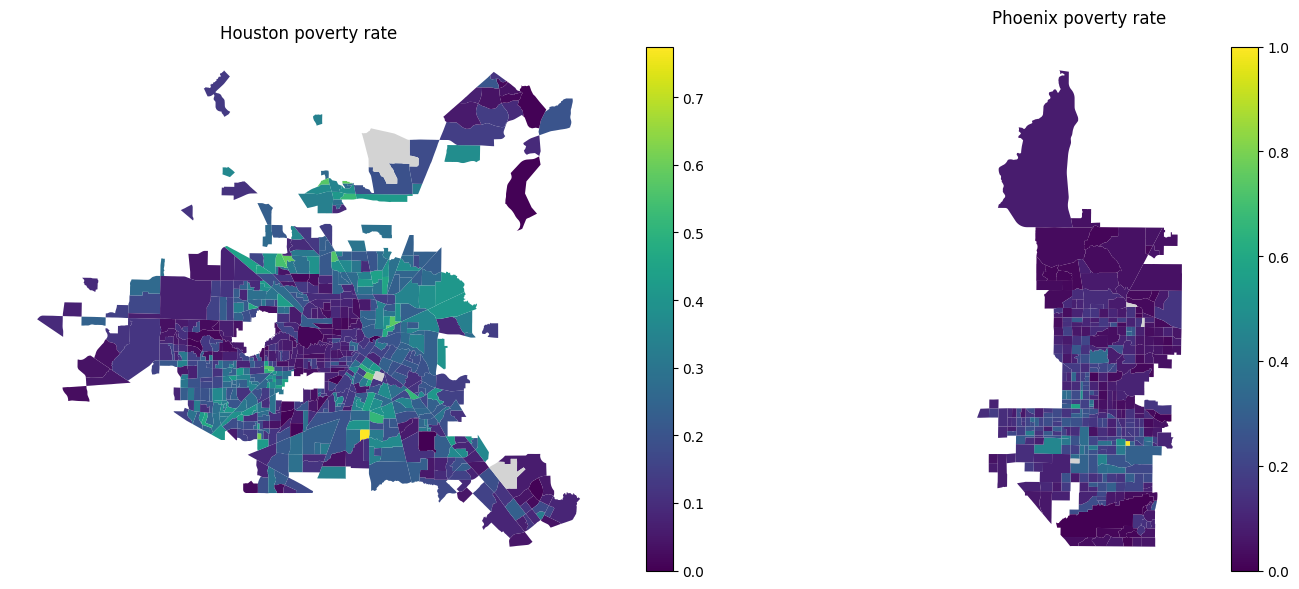

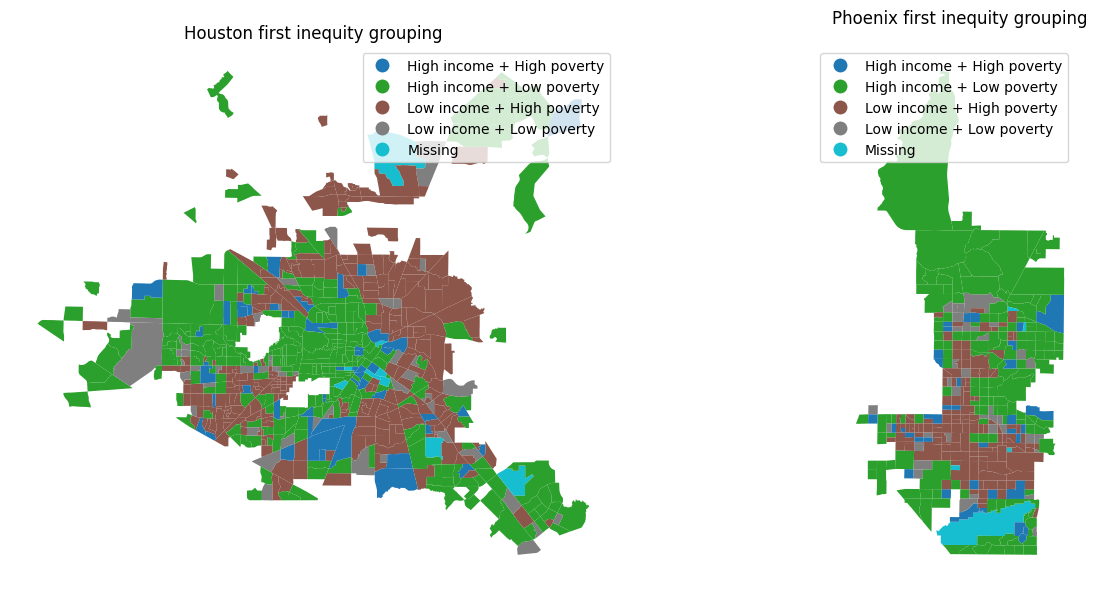


Final v3 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo_poverty.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo_poverty.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/poverty_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/inequity_group_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/poverty_rate_map.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/inequity_group_map.png -> True


In [46]:
# =========================================================
# Step 3B: create first inequity grouping + save + plot
# FIXED VERSION
# =========================================================

def add_city_groups(gdf: gpd.GeoDataFrame, city_name: str) -> gpd.GeoDataFrame:
    out = gdf.copy()

    income_med = out["median_household_income_clean"].median(skipna=True)
    poverty_med = out["poverty_rate"].median(skipna=True)

    out["low_income_flag"] = out["median_household_income_clean"] <= income_med
    out["high_poverty_flag"] = out["poverty_rate"] >= poverty_med

    def assign_group(row):
        if pd.isna(row["median_household_income_clean"]) or pd.isna(row["poverty_rate"]):
            return "Missing"
        if row["low_income_flag"] and row["high_poverty_flag"]:
            return "Low income + High poverty"
        if row["low_income_flag"] and (not row["high_poverty_flag"]):
            return "Low income + Low poverty"
        if (not row["low_income_flag"]) and row["high_poverty_flag"]:
            return "High income + High poverty"
        return "High income + Low poverty"

    out["inequity_group"] = out.apply(assign_group, axis=1)
    out["city"] = city_name

    return out


def build_group_qc(gdf: gpd.GeoDataFrame, city_name: str) -> pd.DataFrame:
    vc = (
        gdf["inequity_group"]
        .value_counts(dropna=False)
        .rename_axis("inequity_group")
        .reset_index(name="count")
    )
    vc["city"] = city_name
    return vc[["city", "inequity_group", "count"]]


houston_master_v3 = add_city_groups(houston_master_v2, "Houston")
phoenix_master_v3 = add_city_groups(phoenix_master_v2, "Phoenix")

group_qc = pd.concat(
    [
        build_group_qc(houston_master_v3, "Houston"),
        build_group_qc(phoenix_master_v3, "Phoenix"),
    ],
    ignore_index=True
)

print("Inequity group counts:")
display(group_qc)

# ---- save clean master with poverty + grouping
houston_master_v3_out = data_processed / "houston" / "houston_master_demo_poverty.gpkg"
phoenix_master_v3_out = data_processed / "phoenix" / "phoenix_master_demo_poverty.gpkg"

for p in [houston_master_v3_out, phoenix_master_v3_out]:
    if p.exists():
        p.unlink()

houston_master_v3.to_file(houston_master_v3_out, layer="tracts", driver="GPKG")
phoenix_master_v3.to_file(phoenix_master_v3_out, layer="tracts", driver="GPKG")

poverty_qc_out = output_dir / "poverty_qc.csv"
group_qc_out = output_dir / "inequity_group_qc.csv"

poverty_qc.to_csv(poverty_qc_out, index=False)
group_qc.to_csv(group_qc_out, index=False)

# ---- Figure 1: poverty rate maps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master_v3.plot(
    column="poverty_rate",
    ax=axes[0],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[0].set_title("Houston poverty rate")
axes[0].set_axis_off()

phoenix_master_v3.plot(
    column="poverty_rate",
    ax=axes[1],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[1].set_title("Phoenix poverty rate")
axes[1].set_axis_off()

plt.tight_layout()
poverty_map_out = figure_dir / "poverty_rate_map.png"
plt.savefig(poverty_map_out, dpi=300, bbox_inches="tight")
plt.show()

# ---- Figure 2: first inequity grouping map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master_v3.plot(
    column="inequity_group",
    ax=axes[0],
    legend=True,
    categorical=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[0].set_title("Houston first inequity grouping")
axes[0].set_axis_off()

phoenix_master_v3.plot(
    column="inequity_group",
    ax=axes[1],
    legend=True,
    categorical=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[1].set_title("Phoenix first inequity grouping")
axes[1].set_axis_off()

plt.tight_layout()
group_map_out = figure_dir / "inequity_group_map.png"
plt.savefig(group_map_out, dpi=300, bbox_inches="tight")
plt.show()

# ---- final file check
final_v3_files = [
    houston_master_v3_out,
    phoenix_master_v3_out,
    poverty_qc_out,
    group_qc_out,
    poverty_map_out,
    group_map_out
]

print("\nFinal v3 file check:")
for p in final_v3_files:
    print(p, "->", p.exists())